In [1]:
import numpy as np
import os
from init_state import generate_initial_state
from classic import *
from quantum_evolve import evolve_quantum
from plot_utils import *
from config import N, sigma_values, position_seeds, t_values



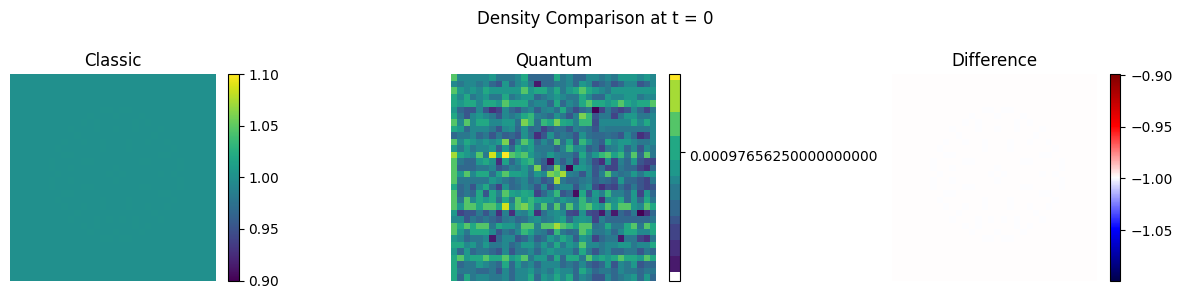

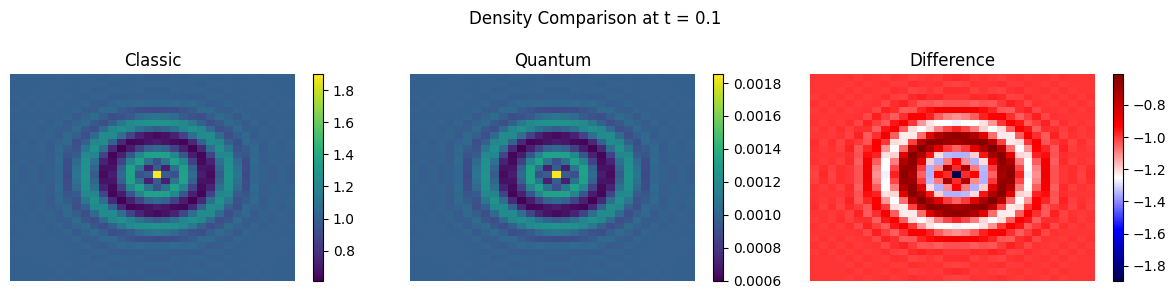

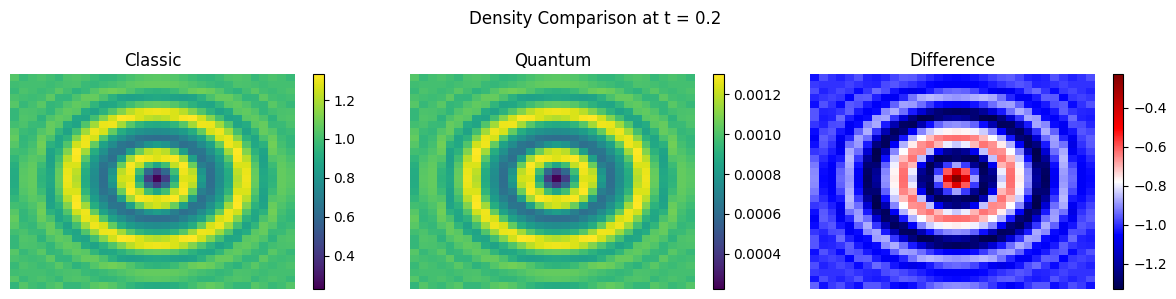

In [2]:
# 初始设置
x0, y0 = 0.0, 0.0
sigma = 1.0
#t_values = [0.0, 1, 2, 10]
#t_values = [0, np.pi / 4, np.pi / 2]
t_values = [0, 0.1, 0.2]
psi1_0, psi2_0 = generate_initial_state(x0, y0, sigma)
initial_state = np.array([psi1_0, psi2_0]).reshape(-1)
initial_state /= np.linalg.norm(initial_state)

# 遍历时间并展示图像
for t in t_values:
    psi1_c = evolve_rk4_baseline(psi1_0, t, N)
    psi2_c = evolve_rk4_baseline(psi2_0, t, N)
    psi1_q, psi2_q = evolve_quantum(5, 5, t, initial_state)

    rho_c = np.abs(psi1_c)**2 + np.abs(psi2_c)**2
    rho_q = np.abs(psi1_q)**2 + np.abs(psi2_q)**2
    scale = np.sqrt(np.sum(rho_c) / np.sum(rho_q))
    psi1_q *= scale
    psi2_q *= scale
    # ***** 关键：缩放后再算一次密度 *****
    # rho_q  = np.abs(psi1_q)**2 + np.abs(psi2_q)**2
    #show_vorticity_comparison(psi1_q, psi2_q, psi1_c, psi2_c, title=f"Vorticity Comparison at t = {t}")
    show_density_comparison(rho_q, rho_c, title=f"Density Comparison at t = {t}")


In [3]:
psi1_test = evolve_rk4_baseline(psi1_0, 0.2, N)
psi2_test = evolve_rk4_baseline(psi2_0, 0.2, N)
mass0  = np.sum(np.abs(psi1_0)**2 + np.abs(psi2_0)**2)
mass_t = np.sum(np.abs(psi1_test)**2 + np.abs(psi2_test)**2)
print("Δmass / mass0 =", (mass_t-mass0)/mass0)


Δmass / mass0 = -1.018394953922197e-07


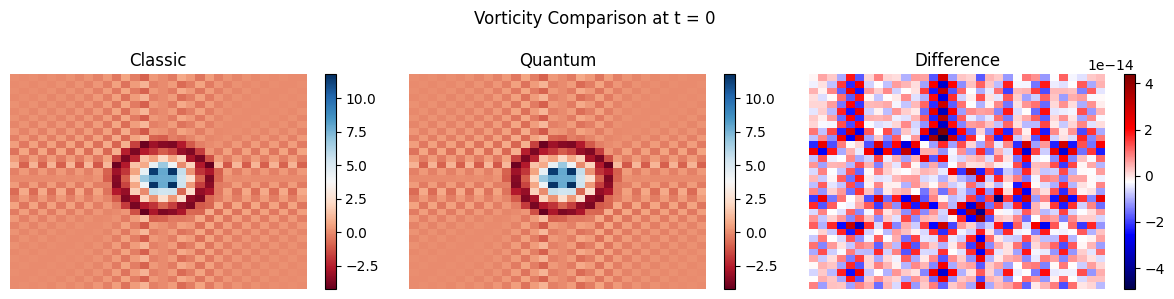

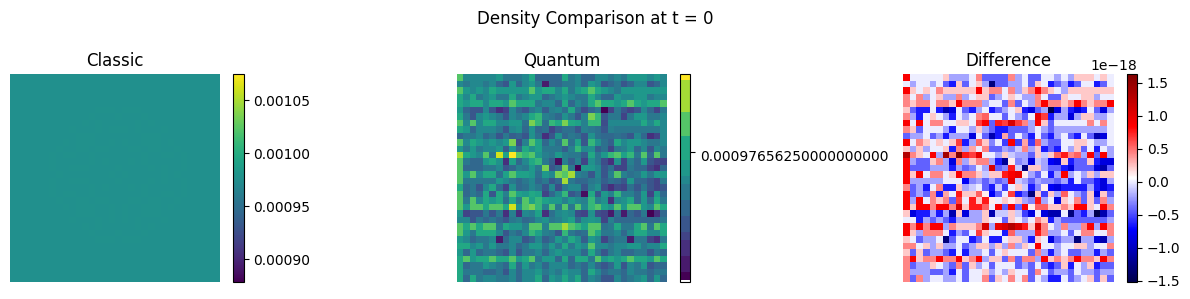

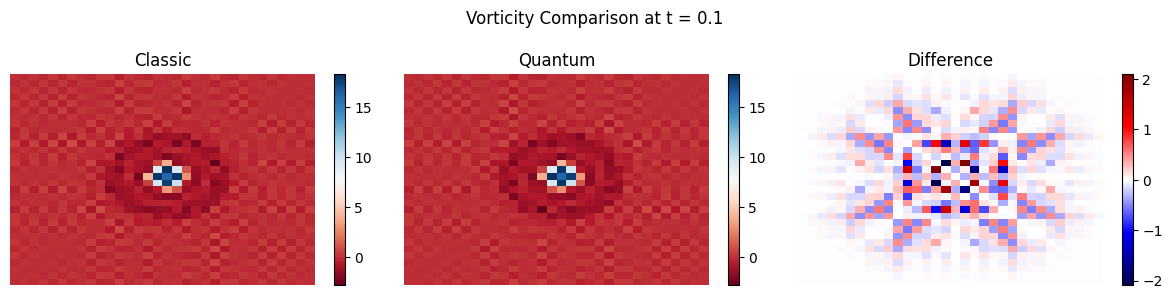

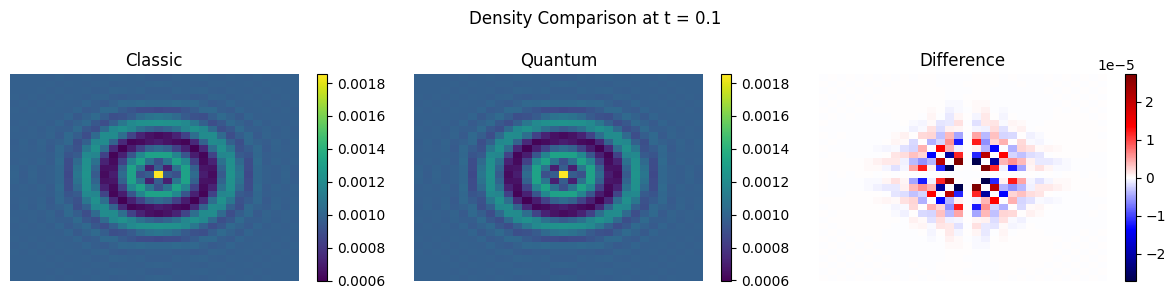

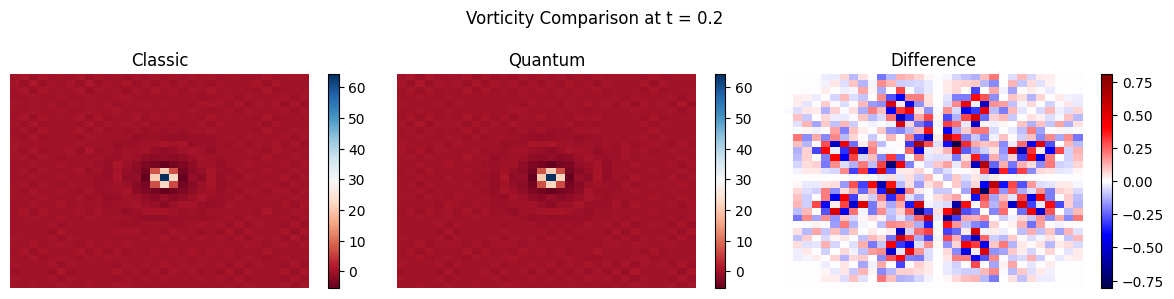

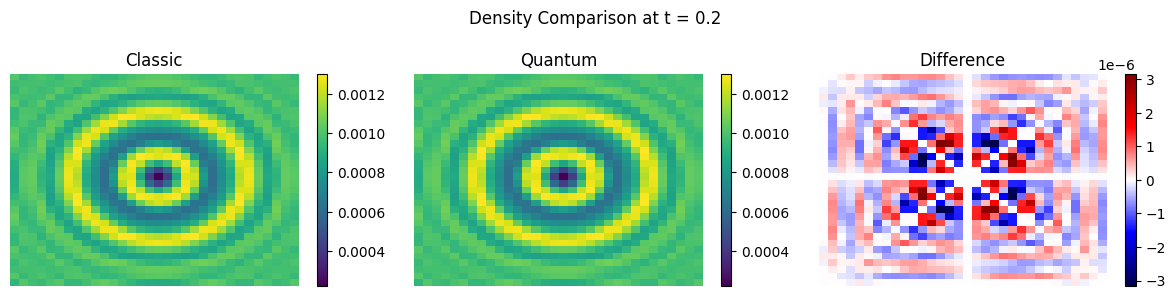

In [4]:
# 遍历时间并展示图像
for t in t_values:
    # --- 量子 & 经典演化 ---
    psi1_c = evolve_rk4_baseline(psi1_0, t, N)
    psi2_c = evolve_rk4_baseline(psi2_0, t, N)
    psi1_q, psi2_q = evolve_quantum(5, 5, t, initial_state)

    # --- 计算初始密度 ---
    rho_c = np.abs(psi1_c)**2 + np.abs(psi2_c)**2
    rho_q = np.abs(psi1_q)**2 + np.abs(psi2_q)**2

    # ------------------------------------------------------------------
    # 关键：用量子侧的“总质量”归一化经典侧，再重算密度
    # ------------------------------------------------------------------
    scale = np.sqrt(np.sum(rho_q) / np.sum(rho_c))
    psi1_c *= scale
    psi2_c *= scale
    rho_c = np.abs(psi1_c)**2 + np.abs(psi2_c)**2  # 重新计算！

    # --- 可视化 ---
    show_vorticity_comparison(psi1_q, psi2_q, psi1_c, psi2_c, title=f"Vorticity Comparison at t = {t}")
    show_density_comparison(rho_q, rho_c,title=f"Density Comparison at t = {t}")
